In [ ]:
# GridPulse: Energy Usage Forecasting

## Predict Energy Demand. Optimize Operational Costs.

GridPulse is an end-to-end machine-learning forecasting project designed to predict future electricity demand from historical energy-consumption data.

### Business Objective

Energy demand changes over time because of:

- time of day
- day of week
- seasonal patterns
- recurring usage behavior
- previous consumption
- unexpected demand peaks

The goal of GridPulse is to transform historical consumption data into actionable forecasts that can support:

- demand planning
- energy procurement
- peak-load management
- battery scheduling
- backup-generator planning
- operational budgeting
- renewable-energy integration

### Modeling Strategy

The project compares:

1. Last-value naive forecasting
2. Seasonal naive forecasting
3. Tree-based machine learning
4. Optional statistical forecasting

The primary machine-learning model uses time-series features such as:

- calendar variables
- lag variables
- rolling statistics
- cyclical time encoding
- seasonal information

### Important Principle

The model must only use information that would have been available at prediction time.

No future observations are used when constructing forecasting features.

SyntaxError: invalid syntax (1945834716.py, line 5)

In [ ]:
## 1. Dataset

This project uses the UCI Individual Household Electric Power Consumption dataset.

The original dataset contains approximately 2.07 million one-minute measurements collected over almost four years.

Important columns include:

- Date
- Time
- Global_active_power
- Global_reactive_power
- Voltage
- Global_intensity
- Sub_metering_1
- Sub_metering_2
- Sub_metering_3

For the GridPulse prototype, the minute-level data will be aggregated into hourly observations.

### Target Definition

The primary target is:

**Hourly Energy Consumption (kWh)**

The original `Global_active_power` variable is measured as average active power in kilowatts.

For hourly energy:

    hourly_energy_kwh = sum(minute_power_kw) / 60

This produces an hourly energy-consumption measure in kWh.

### Source

UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

In [ ]:
#install missing packages without repeatedly installing packages already available
from pathlib import Path
import urllib.request
import sys
import subprocess
import importlib.util
required_packages={
    "pandas":"pandas",
    "numpy":"numpy",
    "matplotlib":"matplotlib",
    "seaborn":"seaborn",
    "sklearn":"scikit-learn",
    "joblib":"joblib",
    "plotly":"plotly"
}
for module_name,package_name in required_packages.items():
  if importlib.util.find_spec(module_name) is None:
    print(f"Installing{package_name}...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        package_name
    ])
if importlib.util.find_spec("xgboost") is None:
  print("Installing xgboost...")
  subprocess.check_call([
      sys.executable,
      "-m",
      "pip",
      "install",
      "-q",
      "xgboost"
  ])
  print("environment ready.")

In [ ]:
import os
import json
import time
import warnings
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import(
    HistGradientBoostingRegressor,
    RandomForestRegressor
)
import joblib
warnings.filterwarnings("ignore")
try:
  from xgboost import XGBRegressor
  XGBOOST_AVAILABLE=True
  print("XGBOOST available")
except Exception:
  XGBOOST_AVAILABLE=False
  print("XGBOOST unavailable. Scikit-learn model will be used.")
print("libraries loaded successfully")

XGBOOST available
libraries loaded successfully


In [ ]:
#if a future client provides a different csv, you can change configurationinstead of rewriting the entire notebook.
PROJECT_DIR= Path("/content/gridpulse")
DATA_DIR= PROJECT_DIR/"data"
RAW_DIR=DATA_DIR/"raw"
PROCESSED_DIR=DATA_DIR/"processed"
OUTPUT_DIR=PROJECT_DIR/"outputs"
FIGURE_DIR=OUTPUT_DIR/"figures"
METRIC_DIR=OUTPUT_DIR/"metrics"
PREDICTION_DIR=OUTPUT_DIR/"predictions"
MODEL_DIR=PROJECT_DIR/"models"
for folder in[
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    METRIC_DIR,
    PREDICTION_DIR,
    MODEL_DIR
]:
    folder.mkdir(parents=True,exist_ok=True)
DATA_COLUMN="timestamp"
TARGET_COLUMN="energy_kwh"
FREQUENCY="h"
FORECAST_HORIZON=24
TEST_SIZE=0.15
VALIDATION_SIZE=0.15
RANDOM_STATE=42
USE_UCI_DATASET=True
CUSTOM_DATA_PATH=None
print("gridpulse configuration loaded.")
print(PROJECT_DIR)
print(FORECAST_HORIZON)
print(FREQUENCY)


gridpulse configuration loaded.
/content/gridpulse
24
h


In [ ]:
from ast import Load
## Configuration for a Future client dataset
a future client dataset should contain at minimum:
### required
a timestamp column:
-timestamp
-datetime
-data+time
and a numerical target such as:
-confusion
-energy_consumption
-hourly_energy_kwh
-Demand
-Load
-Global_active_power
### example
| timestamp | consumption |
|---|---:|
| 2025-01-01 00:00 | 12.4 |
| 2025-01-01 01:00 | 11.8 |
| 2025-01-01 02:00 | 10.9 |

Thr notebook will attempt to identify likely timestamp and target columns automatically,but the final client configuration should always be reviewd manually



SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (711469257.py, line 19)

In [ ]:
# ==========================================
# DOWNLOAD UCI DATASET
# ==========================================

UCI_URL = (
    "https://archive.ics.uci.edu/"
    "static/public/235/"
    "individual+household+electric+power+consumption.zip"
)

UCI_ZIP_PATH = RAW_DIR / "household_power_consumption.zip"
UCI_TXT_PATH = RAW_DIR / "household_power_consumption.txt"

if USE_UCI_DATASET:

    if not UCI_TXT_PATH.exists():

        print("Downloading UCI dataset...")

        try:
            urllib.request.urlretrieve(
                UCI_URL,
                UCI_ZIP_PATH
            )

            print("Download completed.")

            with zipfile.ZipFile(UCI_ZIP_PATH, "r") as zip_ref:
                zip_ref.extractall(RAW_DIR)

            print("Dataset extracted.")

        except Exception as e:

            print("Automatic download failed.")
            print("Error:", e)
            print()
            print("Use the upload cell below to upload the dataset manually.")

    else:
        print("UCI dataset already exists.")

else:
    print("UCI download disabled.")


Download completed.
Dataset extracted.


In [ ]:

if UCI_TXT_PATH.exists():

    print("Loading UCI dataset...")

    raw_df = pd.read_csv(
        UCI_TXT_PATH,
        sep=";",
        na_values="?",
        low_memory=False
    )

elif CUSTOM_DATA_PATH is not None:

    print("Loading custom dataset...")

    custom_path = Path(CUSTOM_DATA_PATH)

    if custom_path.suffix.lower() == ".csv":

        raw_df = pd.read_csv(
            custom_path,
            low_memory=False
        )

    elif custom_path.suffix.lower() in [".txt", ".data"]:

        raw_df = pd.read_csv(
            custom_path,
            sep=None,
            engine="python",
            low_memory=False
        )

    else:

        raise ValueError(
            "Unsupported file format. Please use CSV or TXT."
        )

else:

    raise FileNotFoundError(
        "No dataset found. Upload a CSV/TXT file."
    )

print("Shape:", raw_df.shape)
display(raw_df.head())

Loading UCI dataset...
Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
#inspect date and time
print(raw_df["Date"].head(10).tolist())

print("\nTime values:")
print(raw_df["Time"].head(10).tolist())

['16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006', '16/12/2006']

Time values:
['17:24:00', '17:25:00', '17:26:00', '17:27:00', '17:28:00', '17:29:00', '17:30:00', '17:31:00', '17:32:00', '17:33:00']


In [ ]:
def detect_column(columns,candidates):
  normalized={
      str(col).strip().lower().replace("","_"):col

      for col in columns
  }
  for candidate in candidates:
    candidate_normalized=(
        candidate.lower()
        .replace(" "," _")
    )
    if candidate_normalized in normalized:
      return normalized[candidate_normalized]
  return None
possible_date_columns=[
    "timestamp",
    "datetime",
    "date",
    "time",
    "date_time"
]
possible_target_columns=[
    "energy_kwh",
    "energy_consumption",
    "consumption",
    "demand",
    "load",
    "energy",
    "global_active_power",
    "power"

]
detected_date=detect_column(
    raw_df.columns,
    possible_date_columns
)
detected_target=detect_column(
    raw_df.columns,
    possible_target_columns
)
print(detected_date)
print(detected_target)


None
None


In [ ]:
# create timestamp

raw_df["timestamp"] = pd.to_datetime(
    raw_df["Date"].astype(str).str.strip()
    + " "
    + raw_df["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

print("Total rows:", len(raw_df))

print(
    "Valid timestamps:",
    raw_df["timestamp"].notna().sum()
)

print(
    "Invalid timestamps:",
    raw_df["timestamp"].isna().sum()
)

display(
    raw_df[
        ["Date", "Time", "timestamp"]
    ].head(10)
)

Total rows: 2075259
Valid timestamps: 2075259
Invalid timestamps: 0


,Date,Time,timestamp
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00
5,16/12/2006,17:29:00,2006-12-16 17:29:00
6,16/12/2006,17:30:00,2006-12-16 17:30:00
7,16/12/2006,17:31:00,2006-12-16 17:31:00
8,16/12/2006,17:32:00,2006-12-16 17:32:00
9,16/12/2006,17:33:00,2006-12-16 17:33:00


In [ ]:
#timestamp quality check
print("First timestamp:")
print(raw_df["timestamp"].min())

print("\nLast timestamp:")
print(raw_df["timestamp"].max())

print("\nNumber of unique timestamps:")
print(raw_df["timestamp"].nunique())

First timestamp:
2006-12-16 17:24:00

Last timestamp:
2010-11-26 21:02:00

Number of unique timestamps:
2075259


In [ ]:
# create clean working dataframe

df = raw_df.copy()
df = df.sort_values("timestamp")
df = df.dropna(subset=["timestamp"])
df = df.set_index("timestamp")

print("Clean dataframe shape:", df.shape)

display(df.head())

Clean dataframe shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
# convert measurment to numeric

measurement_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in measurement_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [ ]:
# missing values

missing_summary = pd.DataFrame({
    "missing_count": df[measurement_columns].isna().sum(),
    "missing_percent": (
        df[measurement_columns].isna().mean() * 100
    ).round(2)
})

display(missing_summary)

,missing_count,missing_percent
Global_active_power,25979,1.25
Global_reactive_power,25979,1.25
Voltage,25979,1.25
Global_intensity,25979,1.25
Sub_metering_1,25979,1.25
Sub_metering_2,25979,1.25
Sub_metering_3,25979,1.25


In [ ]:
# handle missing values

for col in measurement_columns:

    # Use time-based interpolation
    df[col] = df[col].interpolate(
        method="time"
    )

    # Handle missing values at the boundaries
    df[col] = df[col].ffill().bfill()

print("Missing values after cleaning:")

display(
    df[measurement_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

Missing values after cleaning:


,missing_count
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
# houtly resampling

hourly_df = (
    df[measurement_columns]
    .resample("h")
    .mean()
)

print("Hourly dataset shape:", hourly_df.shape)

display(hourly_df.head())

Hourly dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [ ]:
# reset index

hourly_df = hourly_df.reset_index()

print("Final hourly dataset shape:")
print(hourly_df.shape)

display(hourly_df.head())

Final hourly dataset shape:
(34589, 8)


,timestamp,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [ ]:
#check impossible values
if "Global_active_power" in df.columns:
  negative_power=(
      df["Global_active_power"]<0

  ).sum()
  print("negative global_active_power values:",negative_power)
  if negative_power>0:
    print("negative power observation will be treated as invalid measurment")
    df.loc[
        df["Global_active_power"]<0,
        "Global_active_power"
    ]=np.nan
  else:
    print("Global_active_power not found."
    "client target validation is required")



negative global_active_power values: 0
Global_active_power not found.client target validation is required


In [ ]:
## Cleaning Decision

Demand peaks should not automatically be removed as outliers.

A high consumption value can represent a real operational event.

Examples:

- industrial equipment startup
- air-conditioning demand
- heating systems
- machinery
- charging infrastructure
- unusually high occupancy

Therefore, GridPulse flags extreme observations for analysis rather than automatically deleting them.

This prevents the forecasting model from learning an artificially smooth version of reality.

SyntaxError: invalid syntax (1618613052.py, line 3)

In [ ]:
# target columns

hourly_df["energy_kwh"] = (
    hourly_df["Global_active_power"] * 1.0
)

print("energy_kwh created successfully.")

display(
    hourly_df[
        ["Global_active_power", "energy_kwh"]
    ].head()
)

energy_kwh created successfully.


,Global_active_power,energy_kwh
0,4.222889,4.222889
1,3.632200,3.632200
2,3.400233,3.400233
3,3.268567,3.268567
4,3.056467,3.056467


In [ ]:
# save clean dataset

PROCESSED_DIR = Path(
    "/content/gridpulse/data/processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLEAN_DATA_PATH = (
    PROCESSED_DIR / "energy_hourly.csv"
)

hourly_df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("Dataset saved successfully.")
print("Path:", CLEAN_DATA_PATH)
print("Shape:", hourly_df.shape)

Dataset saved successfully.
Path: /content/gridpulse/data/processed/energy_hourly.csv
Shape: (34589, 9)


In [ ]:
# verify saved dataset

saved_df = pd.read_csv(
    CLEAN_DATA_PATH
)

print("File exists:", CLEAN_DATA_PATH.exists())
print("Saved shape:", saved_df.shape)

display(saved_df.head())

File exists: True
Saved shape: (34589, 9)


,timestamp,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,energy_kwh
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,4.222889
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.632200
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.400233
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.268567
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,3.056467


In [ ]:
DATA_PATH = Path("/content/gridpulse/data/processed/energy_hourly.csv")
df=pd.read_csv(DATA_PATH)
df["timestamp"]=pd.to_datetime(df["timestamp"])
df=df.sort_values("timestamp").reset_index(drop=True)
print(df.shape)
print(df.head())

(34589, 9)
            timestamp  Global_active_power  Global_reactive_power     Voltage  \
0 2006-12-16 17:00:00             4.222889               0.229000  234.643889   
1 2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2 2006-12-16 19:00:00             3.400233               0.085233  233.232500   
3 2006-12-16 20:00:00             3.268567               0.075100  234.071500   
4 2006-12-16 21:00:00             3.056467               0.076667  237.158667   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0         18.100000             0.0        0.527778       16.861111   
1         15.600000             0.0        6.716667       16.866667   
2         14.503333             0.0        1.433333       16.683333   
3         13.916667             0.0        0.000000       16.783333   
4         13.046667             0.0        0.416667       17.216667   

   energy_kwh  
0    4.222889  
1    3.632200  
2    3.400233  
3    3.2685

In [ ]:
#basic dataset information
print(len(df))
print(len(df.columns))
print(df.columns.tolist())
print(df.dtypes)
print(df["timestamp"].min())
print(df["timestamp"].max)

34589
9
['timestamp', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'energy_kwh']
timestamp                datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
energy_kwh                      float64
dtype: object
2006-12-16 17:00:00
<bound method Series.max of 0       2006-12-16 17:00:00
1       2006-12-16 18:00:00
2       2006-12-16 19:00:00
3       2006-12-16 20:00:00
4       2006-12-16 21:00:00
                ...        
34584   2010-11-26 17:00:00
34585   2010-11-26 18:00:00
34586   2010-11-26 19:00:00
34587   2010-11-26 20:00:00
34588   2010-11-26 21:00:00
Name: timestamp, Length: 34589, dtype: datetime64[ns]>


In [ ]:
missing=df.isnull().sum()
missing_table=pd.DataFrame({
    "missing values":missing,
    "missing percentages":(missing/len(df)*100).round(2)
})
display(missing_table)

,missing values,missing percentages
timestamp,0,0.0
Global_active_power,0,0.0
Global_reactive_power,0,0.0
Voltage,0,0.0
Global_intensity,0,0.0
Sub_metering_1,0,0.0
Sub_metering_2,0,0.0
Sub_metering_3,0,0.0
energy_kwh,0,0.0


In [ ]:
duplicate_timestamps=df["timestamp"].duplicated().sum()
print(duplicate_timestamps)

0


In [ ]:
print(df.shape)
for i, col in enumerate(df.columns):
  print(i,"->",repr(col))
display(df.head())

(34589, 9)
0 -> 'timestamp'
1 -> 'Global_active_power'
2 -> 'Global_reactive_power'
3 -> 'Voltage'
4 -> 'Global_intensity'
5 -> 'Sub_metering_1'
6 -> 'Sub_metering_2'
7 -> 'Sub_metering_3'
8 -> 'energy_kwh'


,timestamp,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,energy_kwh
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,4.222889
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.632200
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.400233
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.268567
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,3.056467


In [ ]:
print(df.dtypes)

timestamp                datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
energy_kwh                      float64
dtype: object


In [ ]:
possible_columns=[
    col for col in df.columns
    if any(word in col.lower() for word in["energy","power","global"])
]
print(possible_columns)

['Global_active_power', 'Global_reactive_power', 'Global_intensity', 'energy_kwh']


In [ ]:

if "Global_active_power" in df.columns:

    df["Global_active_power"] = pd.to_numeric(
        df["Global_active_power"],
        errors="coerce"
    )

    # For hourly data:
    # average kW during a 1-hour period × 1 hour = kWh
    df["energy_kwh"] = df["Global_active_power"]

    print("energy_kwh created successfully!")

    print("\nTarget statistics:")
    display(df["energy_kwh"].describe())

else:
    print("Global_active_power was not found.")
    print("Available columns:")
    print(df.columns.tolist())

energy_kwh created successfully!

Target statistics:


,energy_kwh
count,34589.000000
mean,1.090311
std,0.894323
min,0.124000
25%,0.342867
50%,0.803267
75%,1.578700
max,6.560533


In [ ]:


processed_path = Path(
    "/content/gridpulse/data/processed/energy_hourly.csv"
)

df.to_csv(processed_path, index=False)

print("Saved successfully!")
print("Path:", processed_path)
print("Shape:", df.shape)

Saved successfully!
Path: /content/gridpulse/data/processed/energy_hourly.csv
Shape: (34589, 9)


In [ ]:
check = pd.read_csv(processed_path)

print("Reloaded shape:", check.shape)
print("Columns:")
print(check.columns.tolist())

print("\nenergy_kwh exists:", "energy_kwh" in check.columns)

Reloaded shape: (34589, 9)
Columns:
['timestamp', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'energy_kwh']

energy_kwh exists: True


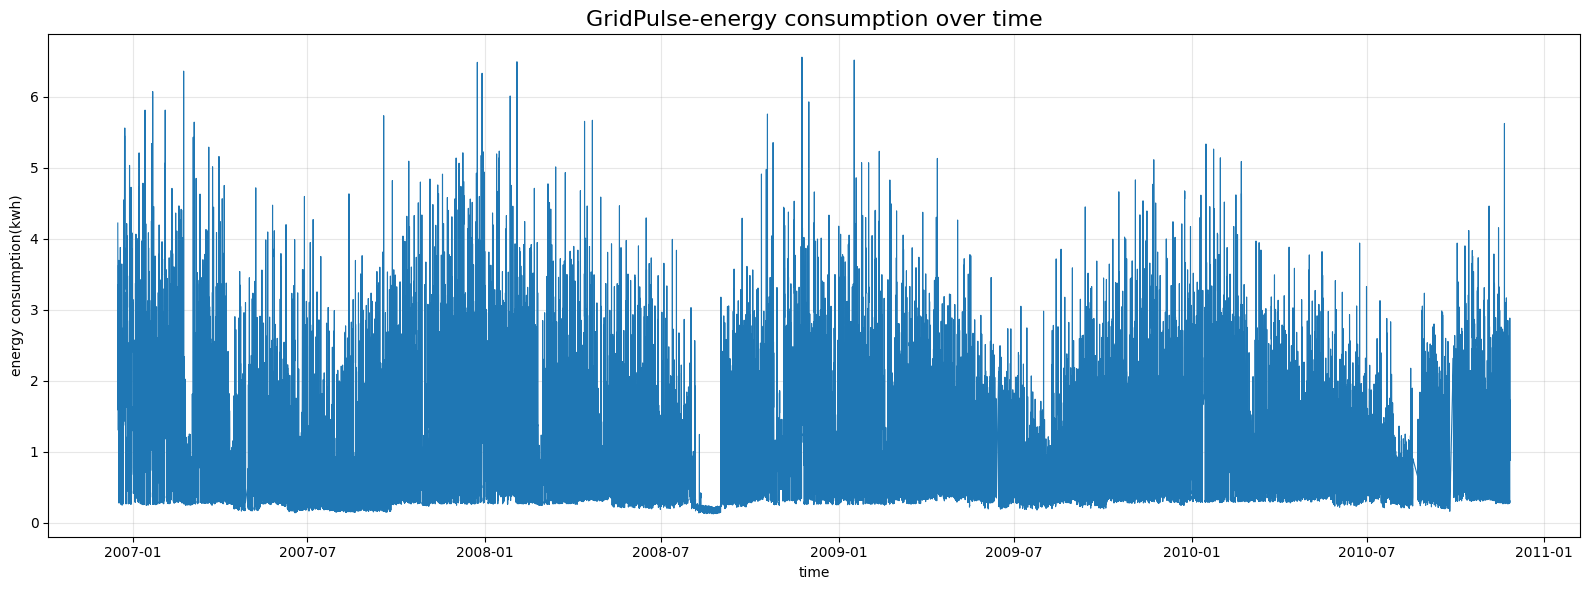

In [ ]:
FIGURES_PATH = Path("/content/gridpulse/outputs/figures")
plt.figure(figsize=(16,6))
plt.plot(
    df["timestamp"],
    df["energy_kwh"],
    linewidth=0.8
)
plt.title(
    "GridPulse-energy consumption over time",
    fontsize=16

)
plt.xlabel("time")
plt.ylabel("energy consumption(kwh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "energy consumption over time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
df["hour"]=df["timestamp"].dt.hour
print(df[["timestamp","hour","energy_kwh"]].head(10))

            timestamp  hour  energy_kwh
0 2006-12-16 17:00:00    17    4.222889
1 2006-12-16 18:00:00    18    3.632200
2 2006-12-16 19:00:00    19    3.400233
3 2006-12-16 20:00:00    20    3.268567
4 2006-12-16 21:00:00    21    3.056467
5 2006-12-16 22:00:00    22    2.200133
6 2006-12-16 23:00:00    23    2.061600
7 2006-12-17 00:00:00     0    1.882467
8 2006-12-17 01:00:00     1    3.349400
9 2006-12-17 02:00:00     2    1.587267


In [ ]:
hourly_pattern=(
    df.groupby("hour")["energy_kwh"]
    .mean()
    .reset_index()

)
hourly_pattern.columns=["hour","average_energy_kwh"]
display(hourly_pattern)

,hour,average_energy_kwh
0,0,0.663418
1,1,0.544698
2,2,0.486809
3,3,0.451589
4,4,0.450522
5,5,0.460220
6,6,0.793647
7,7,1.494386
8,8,1.453509
9,9,1.326026


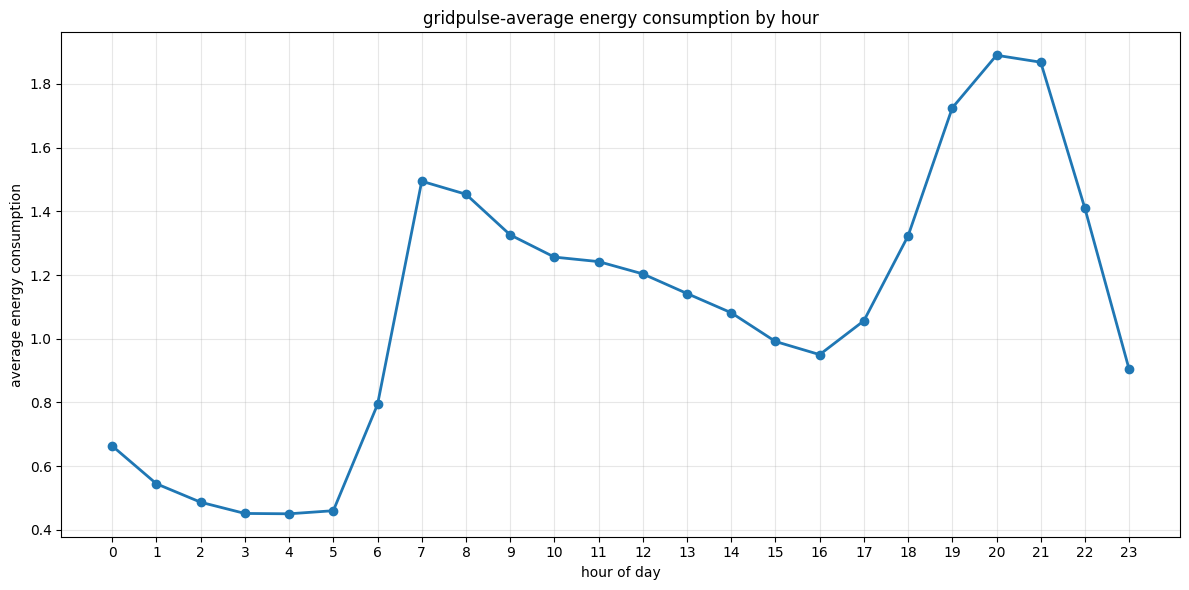

In [ ]:
FIGURES_PATH = Path("/content/gridpulse/outputs/figures")
plt.figure(figsize=(12,6))
plt.plot(
    hourly_pattern["hour"],
    hourly_pattern["average_energy_kwh"],
    marker="o",
    linewidth=2
)
plt.title("gridpulse-average energy consumption by hour")
plt.xlabel("hour of day")
plt.ylabel("average energy consumption")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "average_energy_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
highest_hours=hourly_pattern.sort_values(
    "average_energy_kwh",
    ascending=False

).head(5)
lowest_hours=hourly_pattern.sort_values(
    "average_energy_kwh",
    ascending=True
).head(5)
print("top 5 highest-consuption hours")
display(highest_hours)
print("top 5 lowes consumption hours")
display(lowest_hours)

top 5 highest-consuption hours


,hour,average_energy_kwh
20,20,1.889776
21,21,1.867966
19,19,1.724749
7,7,1.494386
8,8,1.453509


top 5 lowes consumption hours


,hour,average_energy_kwh
4,4,0.450522
3,3,0.451589
5,5,0.460220
2,2,0.486809
1,1,0.544698


In [ ]:
#Day of week feature
df["day_of_week"]=df["timestamp"].dt.dayofweek
day_names={
    0:"Monday",
    1:"Tuesday",
    2:"Wednesday",
    3:"Thursday",
    4:"Friday",
    5:"Saturday",
    6:"Sunday"
}
df["day_name"]=df["day_of_week"].map(day_names)
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Features created.")

display(
    df[
        ["timestamp",
         "day_of_week",
         "day_name",
         "is_weekend"]
    ].head()
)


Features created.


,timestamp,day_of_week,day_name,is_weekend
0,2006-12-16 17:00:00,5,Saturday,1
1,2006-12-16 18:00:00,5,Saturday,1
2,2006-12-16 19:00:00,5,Saturday,1
3,2006-12-16 20:00:00,5,Saturday,1
4,2006-12-16 21:00:00,5,Saturday,1


In [ ]:
weekday_pattern = (
    df.groupby("day_name")["energy_kwh"]
      .mean()
      .reset_index()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_pattern["day_name"] = pd.Categorical(
    weekday_pattern["day_name"],
    categories=weekday_order,
    ordered=True
)

weekday_pattern = weekday_pattern.sort_values(
    "day_name"
)
display(weekday_pattern)

,day_name,energy_kwh
1,Monday,1.001749
5,Tuesday,1.074770
6,Wednesday,1.085026
4,Thursday,0.982072
0,Friday,1.042066
2,Saturday,1.233893
3,Sunday,1.213079


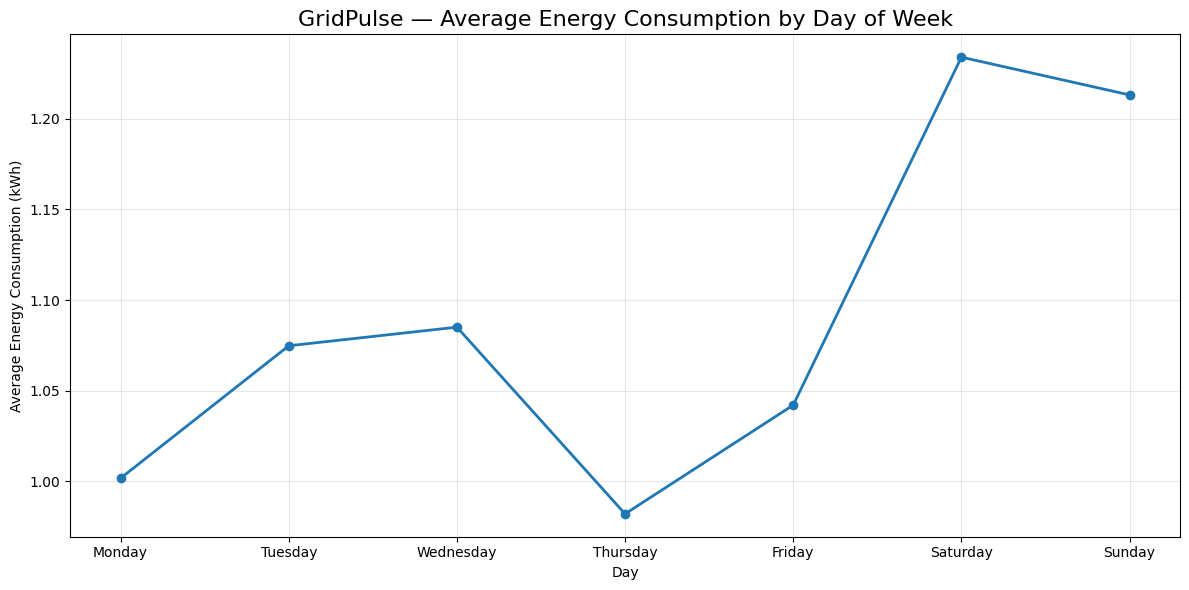

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
plt.figure(figsize=(12,6))

plt.plot(
    weekday_pattern["day_name"],
    weekday_pattern["energy_kwh"],
    marker="o",
    linewidth=2
)

plt.title(
    "GridPulse — Average Energy Consumption by Day of Week",
    fontsize=16
)

plt.xlabel("Day")
plt.ylabel("Average Energy Consumption (kWh)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "energy_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#weekend vs weekday
weekend_comparison = (
    df.groupby("is_weekend")["energy_kwh"]
      .mean()
      .reset_index()
)

weekend_comparison["label"] = (
    weekend_comparison["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

display(weekend_comparison)

,is_weekend,energy_kwh,label
0,0,1.037136,Weekday
1,1,1.223468,Weekend


In [ ]:
df["month"] = df["timestamp"].dt.month

df["month_name"] = df["timestamp"].dt.month_name()

df["quarter"] = df["timestamp"].dt.quarter

print("Monthly features created.")

display(
    df[
        [
            "timestamp",
            "month",
            "month_name",
            "quarter"
        ]
    ].head()
)

Monthly features created.


,timestamp,month,month_name,quarter
0,2006-12-16 17:00:00,12,December,4
1,2006-12-16 18:00:00,12,December,4
2,2006-12-16 19:00:00,12,December,4
3,2006-12-16 20:00:00,12,December,4
4,2006-12-16 21:00:00,12,December,4


In [ ]:
monthly_pattern = (
    df.groupby("month")["energy_kwh"]
      .mean()
      .reset_index()
)

display(monthly_pattern)

,month,energy_kwh
0,1,1.467443
1,2,1.300329
2,3,1.226522
3,4,1.032375
4,5,1.029572
5,6,0.915760
6,7,0.700603
7,8,0.579623
8,9,0.983779
9,10,1.137302


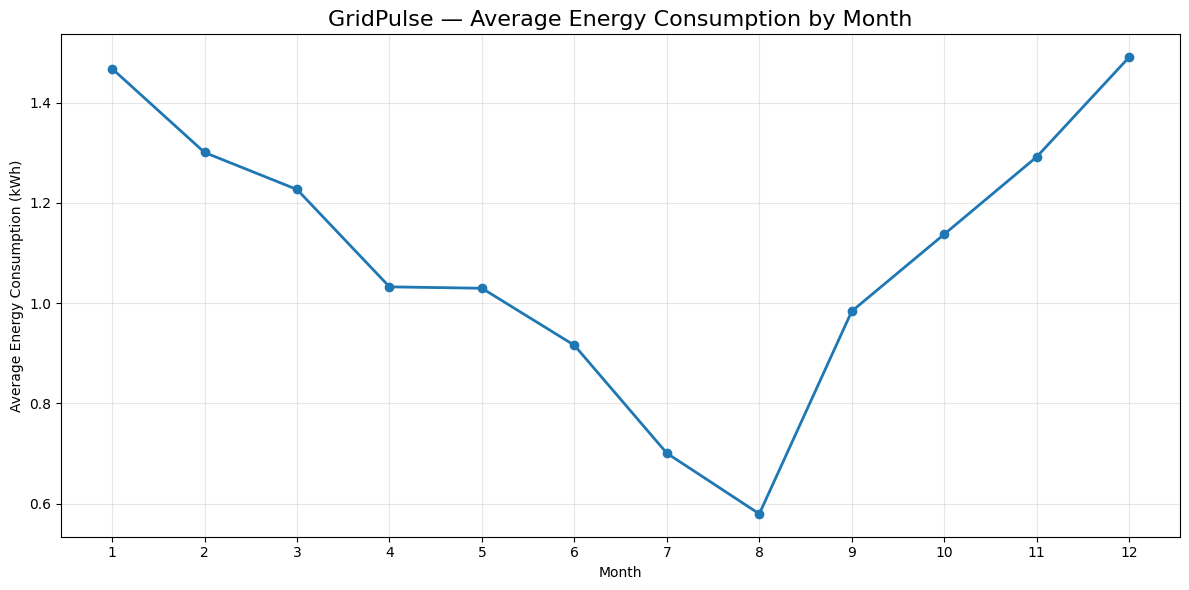

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_pattern["month"],
    monthly_pattern["energy_kwh"],
    marker="o",
    linewidth=2
)

plt.title(
    "GridPulse — Average Energy Consumption by Month",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Average Energy Consumption (kWh)")

plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH /
    "energy_by_month.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#energy by quarter

quarterly_pattern = (
    df.groupby("quarter")["energy_kwh"]
      .mean()
      .reset_index()
)

display(quarterly_pattern)

,quarter,energy_kwh
0,1,1.332379
1,2,0.992976
2,3,0.752178
3,4,1.298454


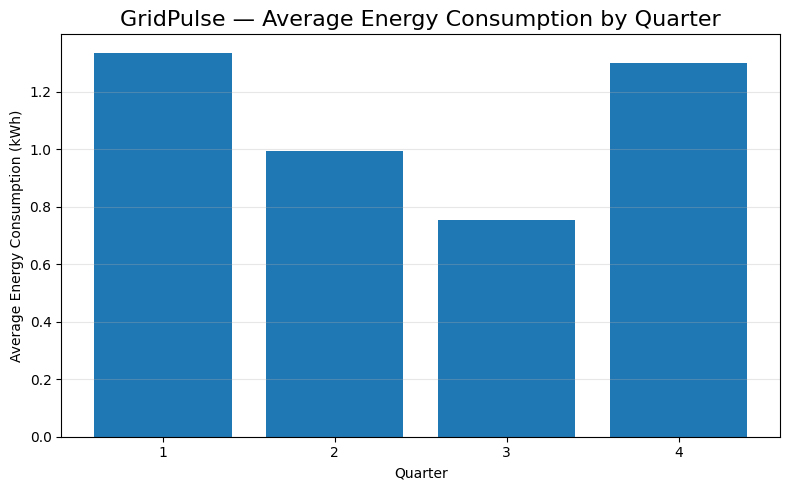

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(8,5))

plt.bar(
    quarterly_pattern["quarter"].astype(str),
    quarterly_pattern["energy_kwh"]
)

plt.title(
    "GridPulse — Average Energy Consumption by Quarter",
    fontsize=16
)

plt.xlabel("Quarter")
plt.ylabel("Average Energy Consumption (kWh)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "energy_by_quarter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#rolling features

df["rolling_mean_24"] = (
    df["energy_kwh"]
    .rolling(window=24)
    .mean()
)

df["rolling_mean_168"] = (
    df["energy_kwh"]
    .rolling(window=168)
    .mean()
)

df["rolling_std_24"] = (
    df["energy_kwh"]
    .rolling(window=24)
    .std()
)

print("Rolling features created.")

display(
    df[
        [
            "energy_kwh",
            "rolling_mean_24",
            "rolling_mean_168",
            "rolling_std_24"
        ]
    ].head(30)
)

Rolling features created.


,energy_kwh,rolling_mean_24,rolling_mean_168,rolling_std_24
0,4.222889,NaN,NaN,NaN
1,3.632200,NaN,NaN,NaN
2,3.400233,NaN,NaN,NaN
3,3.268567,NaN,NaN,NaN
4,3.056467,NaN,NaN,NaN
5,2.200133,NaN,NaN,NaN
6,2.061600,NaN,NaN,NaN
7,1.882467,NaN,NaN,NaN
8,3.349400,NaN,NaN,NaN
9,1.587267,NaN,NaN,NaN


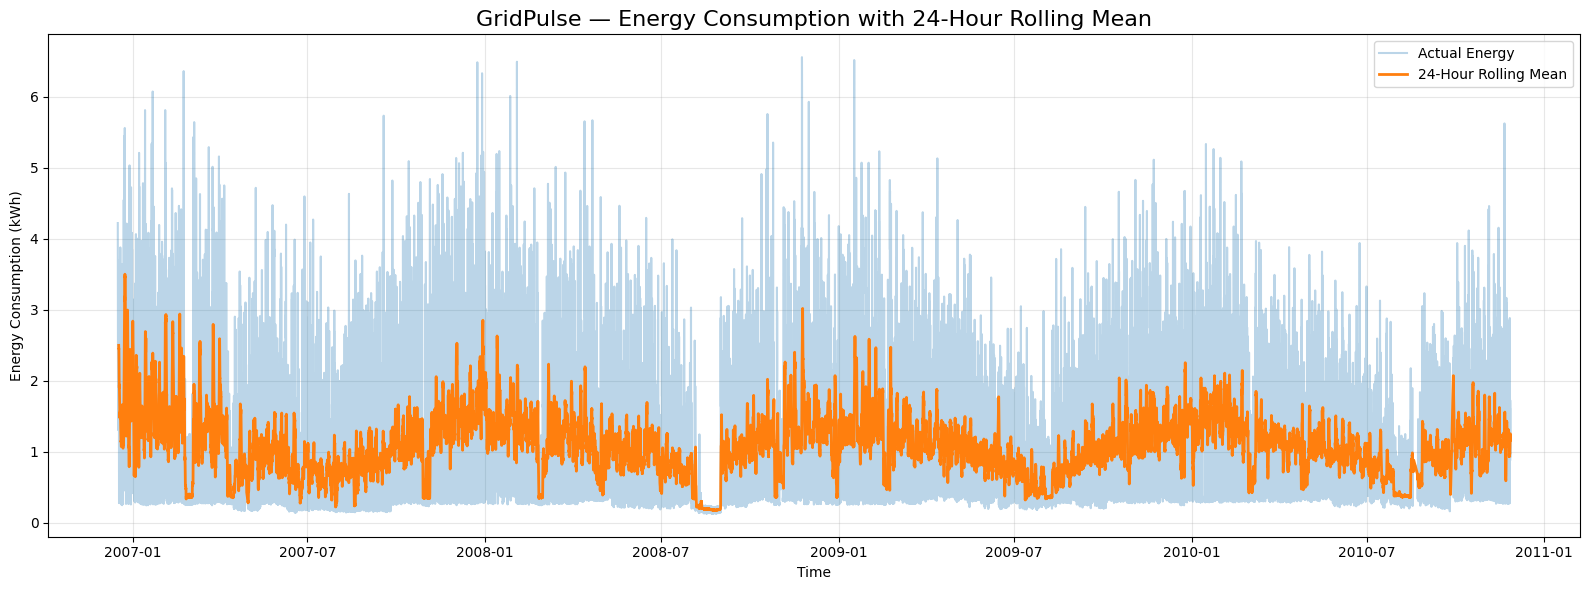

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
plt.figure(figsize=(16,6))

plt.plot(
    df["timestamp"],
    df["energy_kwh"],
    alpha=0.3,
    label="Actual Energy"
)

plt.plot(
    df["timestamp"],
    df["rolling_mean_24"],
    linewidth=2,
    label="24-Hour Rolling Mean"
)

plt.title(
    "GridPulse — Energy Consumption with 24-Hour Rolling Mean",
    fontsize=16
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "rolling_mean_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

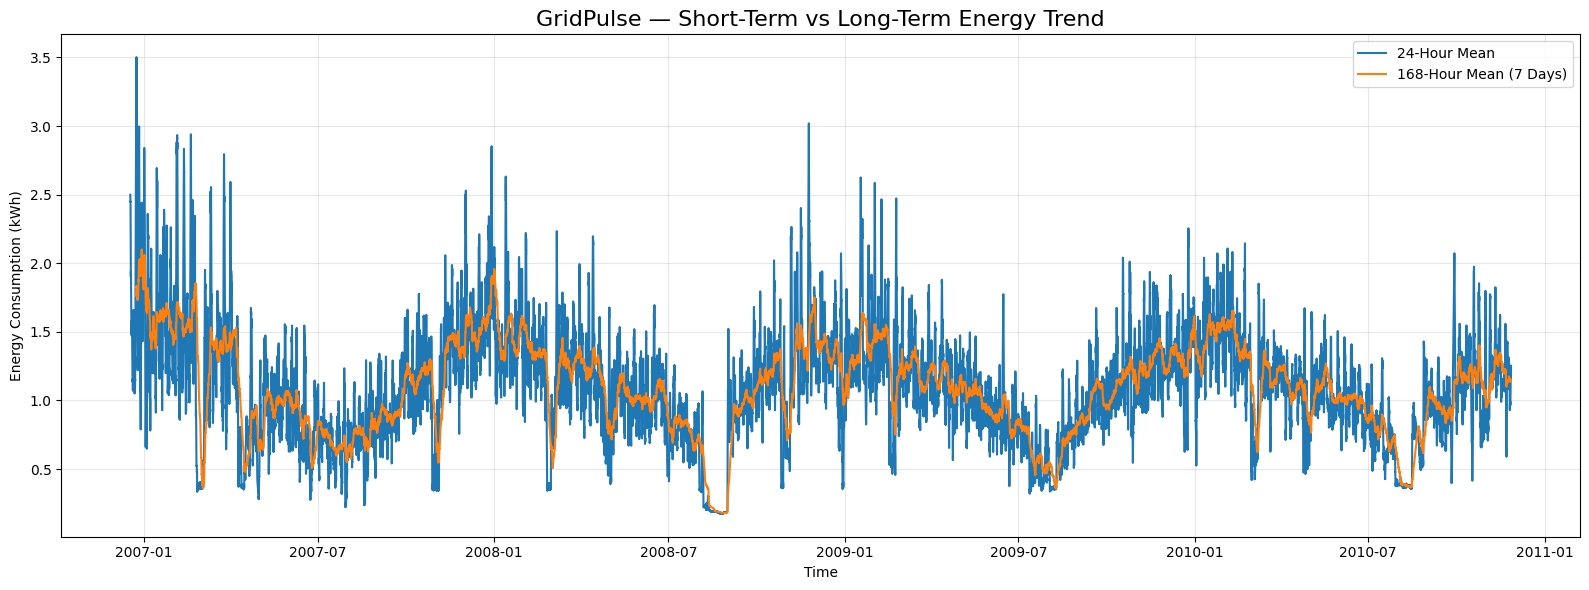

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(16,6))

plt.plot(
    df["timestamp"],
    df["rolling_mean_24"],
    label="24-Hour Mean"
)

plt.plot(
    df["timestamp"],
    df["rolling_mean_168"],
    label="168-Hour Mean (7 Days)"
)

plt.title(
    "GridPulse — Short-Term vs Long-Term Energy Trend",
    fontsize=16
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "short term vs long temr energy trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

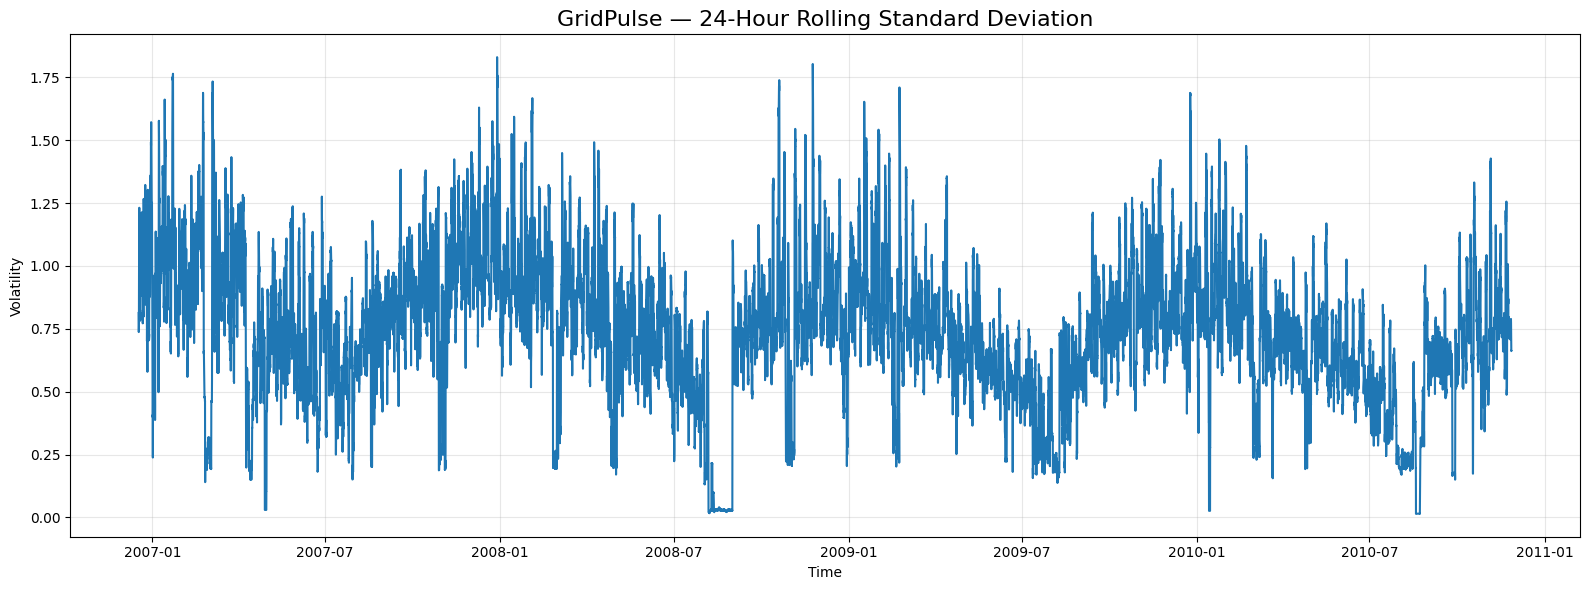

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(16,6))

plt.plot(
    df["timestamp"],
    df["rolling_std_24"]
)

plt.title(
    "GridPulse — 24-Hour Rolling Standard Deviation",
    fontsize=16
)

plt.xlabel("Time")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "24 hour rolling standard deviation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

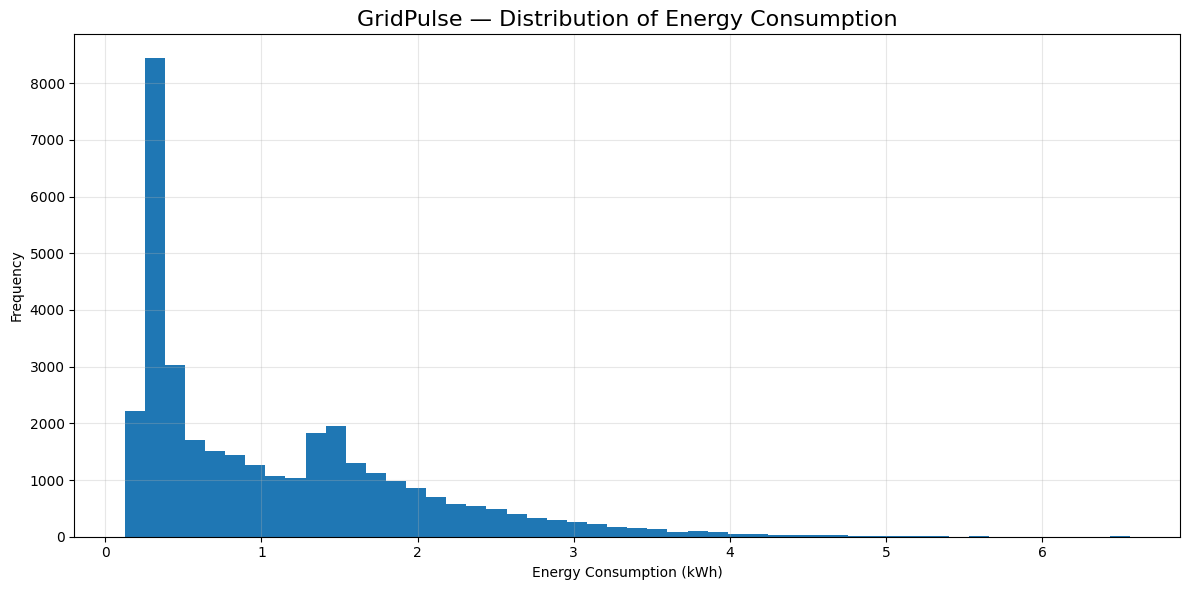

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(12,6))

plt.hist(
    df["energy_kwh"],
    bins=50
)

plt.title(
    "GridPulse — Distribution of Energy Consumption",
    fontsize=16
)

plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "distribution of energy consumption.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

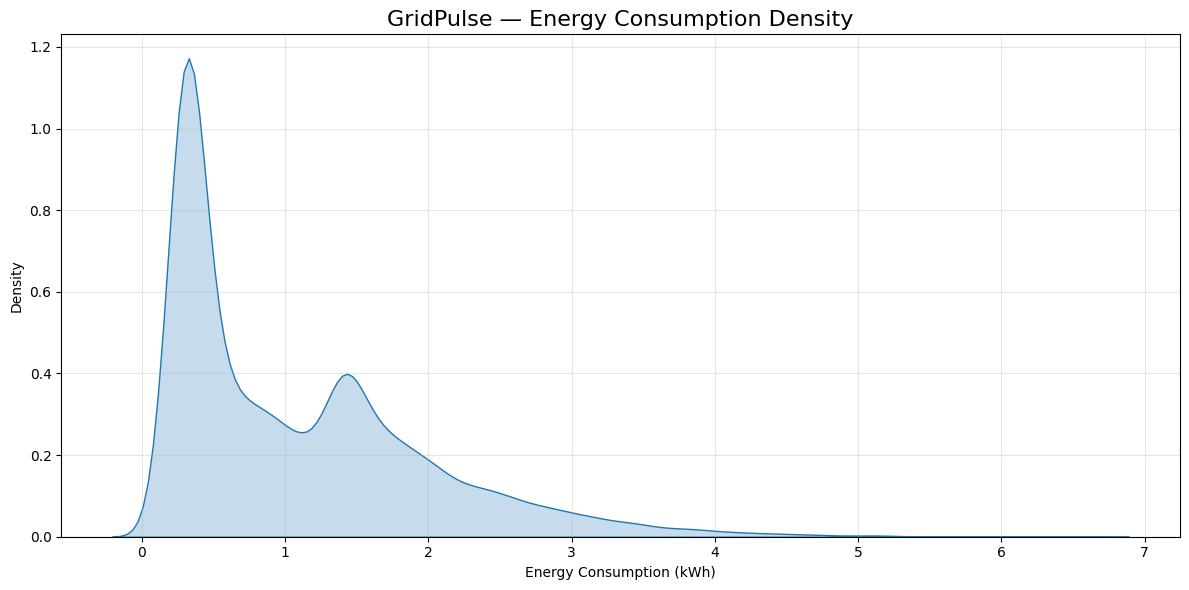

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
plt.figure(figsize=(12,6))

sns.kdeplot(
    df["energy_kwh"],
    fill=True
)

plt.title(
    "GridPulse — Energy Consumption Density",
    fontsize=16
)

plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "energy consumption density.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

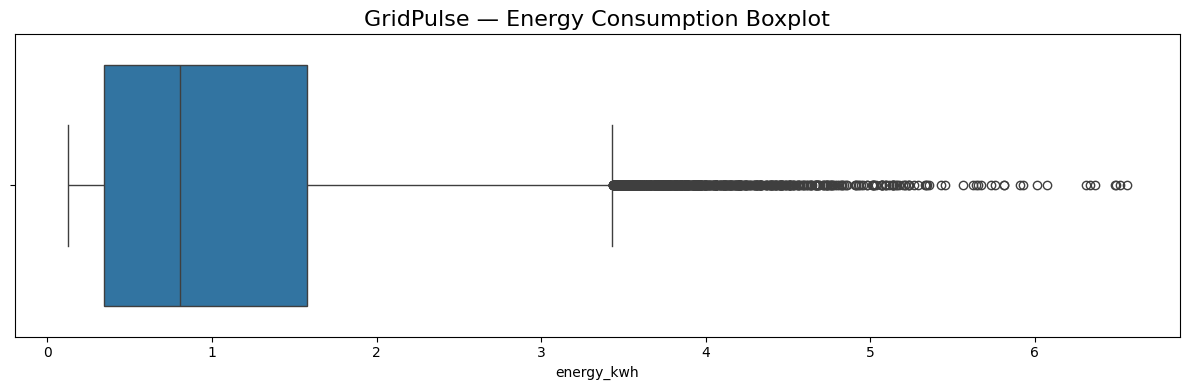

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["energy_kwh"]
)

plt.title(
    "GridPulse — Energy Consumption Boxplot",
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "energy consumption boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:

skewness = df["energy_kwh"].skew()

print("Skewness:", round(skewness, 4))

Skewness: 1.3008


In [ ]:

Q1 = df["energy_kwh"].quantile(0.25)
Q3 = df["energy_kwh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["energy_kwh"] < lower_bound)
    |
    (df["energy_kwh"] > upper_bound)
]

print("Q1:", round(Q1,3))
print("Q3:", round(Q3,3))
print("IQR:", round(IQR,3))

print("\nOutlier Count:", len(outliers))

print(
    "Outlier Percentage:",
    round(
        len(outliers)/len(df)*100,
        2
    ),
    "%"
)

Q1: 0.343
Q3: 1.579
IQR: 1.236

Outlier Count: 735
Outlier Percentage: 2.12 %


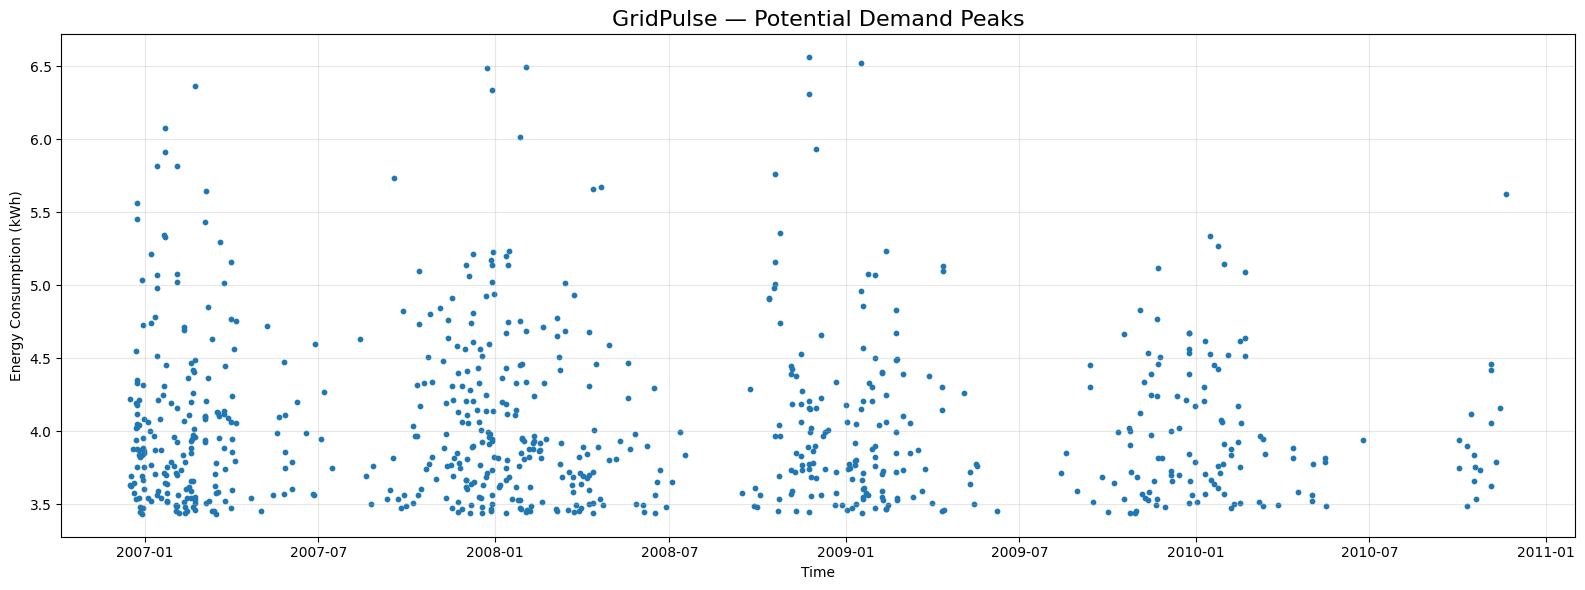

In [ ]:
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

plt.figure(figsize=(16,6))

plt.scatter(
    outliers["timestamp"],
    outliers["energy_kwh"],
    s=10
)

plt.title(
    "GridPulse — Potential Demand Peaks",
    fontsize=16
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "potential demand peak.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

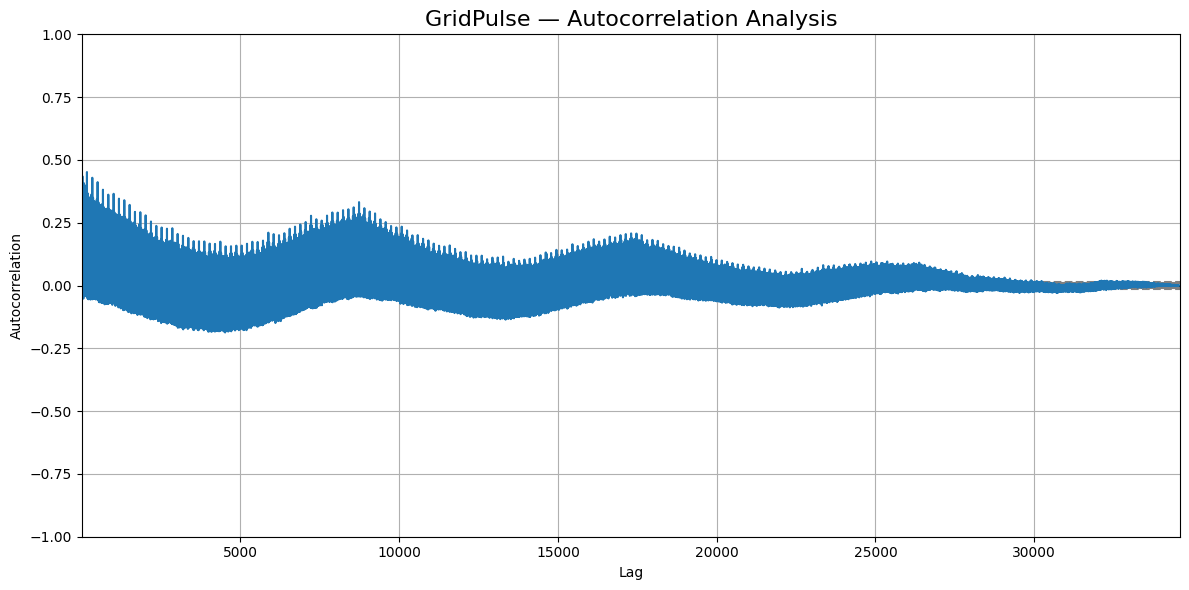

In [ ]:

from pandas.plotting import autocorrelation_plot
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
plt.figure(figsize=(12,6))

autocorrelation_plot(
    df["energy_kwh"]
)

plt.title(
    "GridPulse — Autocorrelation Analysis",
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "autocorrelation_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

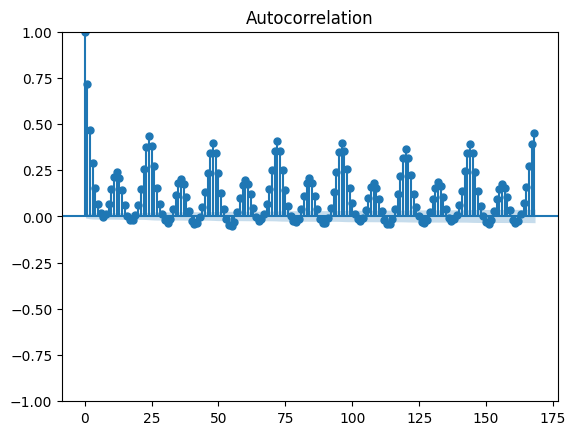

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    df["energy_kwh"],
    lags=168
)

plt.show()

In [ ]:
#calendar feature
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek

df["day_of_month"] = df["timestamp"].dt.day

df["week_of_year"] = (
    df["timestamp"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["month"] = df["timestamp"].dt.month

df["quarter"] = df["timestamp"].dt.quarter

df["day_of_year"] = df["timestamp"].dt.dayofyear

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Calendar features created.")

display(
    df[
        [
            "timestamp",
            "hour",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "month",
            "quarter",
            "day_of_year",
            "is_weekend"
        ]
    ].head()
)

Calendar features created.


,timestamp,hour,day_of_week,day_of_month,week_of_year,month,quarter,day_of_year,is_weekend
0,2006-12-16 17:00:00,17,5,16,50,12,4,350,1
1,2006-12-16 18:00:00,18,5,16,50,12,4,350,1
2,2006-12-16 19:00:00,19,5,16,50,12,4,350,1
3,2006-12-16 20:00:00,20,5,16,50,12,4,350,1
4,2006-12-16 21:00:00,21,5,16,50,12,4,350,1


In [ ]:

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

print("Cyclical features created.")

display(
    df[
        [
            "hour",
            "hour_sin",
            "hour_cos",
            "month",
            "month_sin",
            "month_cos"
        ]
    ].head()
)

Cyclical features created.


,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,17,-0.965926,-2.588190e-01,12,-2.449294e-16,1.0
1,18,-1.000000,-1.836970e-16,12,-2.449294e-16,1.0
2,19,-0.965926,2.588190e-01,12,-2.449294e-16,1.0
3,20,-0.866025,5.000000e-01,12,-2.449294e-16,1.0
4,21,-0.707107,7.071068e-01,12,-2.449294e-16,1.0


In [ ]:
#lag features
TARGET = "energy_kwh"

df["lag_1"] = df[TARGET].shift(1)

df["lag_2"] = df[TARGET].shift(2)

df["lag_3"] = df[TARGET].shift(3)

df["lag_24"] = df[TARGET].shift(24)

df["lag_48"] = df[TARGET].shift(48)

df["lag_168"] = df[TARGET].shift(168)

print("Lag features created.")

display(
    df[
        [
            TARGET,
            "lag_1",
            "lag_24",
            "lag_48",
            "lag_168"
        ]
    ].head(30)
)

Lag features created.


,energy_kwh,lag_1,lag_24,lag_48,lag_168
0,4.222889,NaN,NaN,NaN,NaN
1,3.632200,4.222889,NaN,NaN,NaN
2,3.400233,3.632200,NaN,NaN,NaN
3,3.268567,3.400233,NaN,NaN,NaN
4,3.056467,3.268567,NaN,NaN,NaN
5,2.200133,3.056467,NaN,NaN,NaN
6,2.061600,2.200133,NaN,NaN,NaN
7,1.882467,2.061600,NaN,NaN,NaN
8,3.349400,1.882467,NaN,NaN,NaN
9,1.587267,3.349400,NaN,NaN,NaN


In [ ]:
# ============================================
# ROLLING FEATURES
# ============================================

df["rolling_mean_3"] = (
    df[TARGET]
    .shift(1)
    .rolling(3)
    .mean()
)

df["rolling_mean_6"] = (
    df[TARGET]
    .shift(1)
    .rolling(6)
    .mean()
)

df["rolling_mean_24"] = (
    df[TARGET]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df[TARGET]
    .shift(1)
    .rolling(24)
    .std()
)

print("Rolling features created.")

Rolling features created.


In [ ]:
for col in [
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_std_24"
]:
    print(col, "->", col in df.columns)

rolling_mean_3 -> True
rolling_mean_6 -> True
rolling_mean_24 -> True
rolling_std_24 -> True


In [ ]:

df["expanding_mean"] = (
    df[TARGET]
    .shift(1)
    .expanding()
    .mean()
)

print("Expanding mean created.")

Expanding mean created.


In [ ]:

feature_missing = (
    df.isnull()
      .sum()
      .sort_values(
          ascending=False
      )
)

display(feature_missing.head(20))

,0
lag_168,168
rolling_mean_168,167
lag_48,48
rolling_std_24,24
lag_24,24
rolling_mean_24,24
rolling_mean_6,6
rolling_mean_3,3
lag_3,3
lag_2,2


In [ ]:
# model features

TARGET = "energy_kwh"

FEATURES = [

    "hour",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "quarter",
    "day_of_year",
    "is_weekend",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "lag_1",
    "lag_2",
    "lag_3",

    "lag_24",
    "lag_48",
    "lag_168",

    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",

    "rolling_std_24",

    "expanding_mean"
]

print("Number of features:", len(FEATURES))

for feature in FEATURES:
    print(feature)

Number of features: 23
hour
day_of_week
day_of_month
week_of_year
month
quarter
day_of_year
is_weekend
hour_sin
hour_cos
month_sin
month_cos
lag_1
lag_2
lag_3
lag_24
lag_48
lag_168
rolling_mean_3
rolling_mean_6
rolling_mean_24
rolling_std_24
expanding_mean


In [ ]:
#rebuild model dataset

df_model = df.dropna().copy()

print("df_model shape:", df_model.shape)

df_model shape: (34421, 35)


In [ ]:
missing_features = [
    f for f in FEATURES
    if f not in df_model.columns
]

print("Missing features:")
print(missing_features)

Missing features:
[]


In [ ]:
# final model dataset

X = df_model[FEATURES]

y = df_model[TARGET]

print("Feature matrix shape:", X.shape)

print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (34421, 23)
Target shape: (34421,)


,hour,day_of_week,day_of_month,week_of_year,month,quarter,day_of_year,is_weekend,hour_sin,hour_cos,...,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_6,rolling_mean_24,rolling_std_24,expanding_mean
168,17,5,23,51,12,4,357,1,-0.965926,-2.588190e-01,...,4.049100,3.757967,1.496800,1.752633,4.222889,4.052056,3.608378,2.934890,0.990187,1.763888
169,18,5,23,51,12,4,357,1,-1.000000,-1.836970e-16,...,4.349100,4.049100,2.686967,2.443300,3.632200,4.616911,3.990633,3.099713,1.066674,1.785714
170,19,5,23,51,12,4,357,1,-0.965926,2.588190e-01,...,5.452533,4.349100,3.938167,2.197133,3.400233,4.560344,4.149067,3.149397,1.074356,1.798030
171,20,5,23,51,12,4,357,1,-0.866025,5.000000e-01,...,3.879400,5.452533,3.536067,2.437367,3.268567,4.483256,4.267656,3.156883,1.080699,1.811596
172,21,5,23,51,12,4,357,1,-0.707107,7.071068e-01,...,4.117833,3.879400,4.548667,0.982267,3.056467,4.059544,4.338228,3.183772,1.098426,1.825374


In [ ]:
print(X.shape)
print(y.shape)
print(X.isnull().sum().sum())
print(y.isnull().sum())

(34421, 23)
(34421,)
0
0


In [ ]:
# chronological split

n = len(df_model)

train_end = int(n * 0.70)

valid_end = int(n * 0.85)

train_df = df_model.iloc[:train_end]

valid_df = df_model.iloc[train_end:valid_end]

test_df = df_model.iloc[valid_end:]

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (24094, 35)
Validation shape: (5163, 35)
Test shape: (5164, 35)


In [ ]:
X_train=train_df[FEATURES]
y_train=train_df["energy_kwh"]
X_valid=valid_df[FEATURES]
y_valid=valid_df["energy_kwh"]
x_test=test_df[FEATURES]
y_test=test_df["energy_kwh"]
print(X_train.shape)
print(X_valid.shape)
print(x_test.shape)

(24094, 23)
(5163, 23)
(5164, 23)


In [ ]:
print("TRAIN")

print(train_df["timestamp"].min())
print(train_df["timestamp"].max())

print("\nVALIDATION")

print(valid_df["timestamp"].min())
print(valid_df["timestamp"].max())

print("\nTEST")

print(test_df["timestamp"].min())
print(test_df["timestamp"].max())

TRAIN
2006-12-23 17:00:00
2009-09-22 14:00:00

VALIDATION
2009-09-22 15:00:00
2010-04-25 17:00:00

TEST
2010-04-25 18:00:00
2010-11-26 21:00:00


In [ ]:
#forecast metrics

import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def safe_mape(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    mask = y_true != 0

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )

def smape(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    return (
        100
        * np.mean(
            2 * np.abs(y_pred - y_true)
            /
            (
                np.abs(y_true)
                +
                np.abs(y_pred)
                + 1e-8
            )
        )
    )

def evaluate_forecast(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = safe_mape(
        y_true,
        y_pred
    )

    smape_value = smape(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return pd.DataFrame({

        "Model":[model_name],

        "MAE":[mae],

        "RMSE":[rmse],

        "MAPE":[mape],

        "sMAPE":[smape_value],

        "R2":[r2]

    })

print("Metrics ready.")

Metrics ready.


In [ ]:
#last value baseline
last_value_pred = test_df["lag_1"]

baseline_1_results = evaluate_forecast(

    y_test,

    last_value_pred,

    "Last Value Baseline"

)

baseline_1_results

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Last Value Baseline,0.372487,0.574542,44.777808,37.367689,0.329966


In [ ]:
# seaonal baseline

seasonal_pred = test_df["lag_24"]

baseline_2_results = evaluate_forecast(

    y_test,

    seasonal_pred,

    "Seasonal Naive (24h)"

)

baseline_2_results

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Seasonal Naive (24h),0.502766,0.748858,65.889689,48.559385,-0.138288


In [ ]:
#baseline comparsion

baseline_results = pd.concat(

    [

        baseline_1_results,

        baseline_2_results

    ],

    ignore_index=True

)

baseline_results

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,Last Value Baseline,0.372487,0.574542,44.777808,37.367689,0.329966
1,Seasonal Naive (24h),0.502766,0.748858,65.889689,48.559385,-0.138288


In [ ]:
baseline_results.to_csv(

    "/content/gridpulse/outputs/metrics/baseline_results.csv",

    index=False

)

print("Saved.")

Saved.


In [ ]:
# install XGBOOT

try:
    from xgboost import XGBRegressor

    print("XGBoost already installed.")

except:

    !pip install xgboost -q

    from xgboost import XGBRegressor

    print("XGBoost installed.")

XGBoost already installed.


In [ ]:
# Train XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    objective="reg:squarederror"
)

xgb_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


In [ ]:
#validation forcast
valid_pred = xgb_model.predict(X_valid)

validation_results = evaluate_forecast(

    y_valid,

    valid_pred,

    "XGBoost Validation"

)

validation_results

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,XGBoost Validation,0.370719,0.532141,40.451776,31.822715,0.636901


In [ ]:
#test forcast
test_pred = xgb_model.predict(x_test)

xgb_results = evaluate_forecast(

    y_test,

    test_pred,

    "XGBoost"

)

xgb_results

,Model,MAE,RMSE,MAPE,sMAPE,R2
0,XGBoost,0.31291,0.453928,41.71837,33.727678,0.581759


In [ ]:
#model comparision
all_results = pd.concat(

    [

        baseline_results,

        xgb_results

    ],

    ignore_index=True

)

all_results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,MAPE,sMAPE,R2
2,XGBoost,0.312910,0.453928,41.718370,33.727678,0.581759
0,Last Value Baseline,0.372487,0.574542,44.777808,37.367689,0.329966
1,Seasonal Naive (24h),0.502766,0.748858,65.889689,48.559385,-0.138288


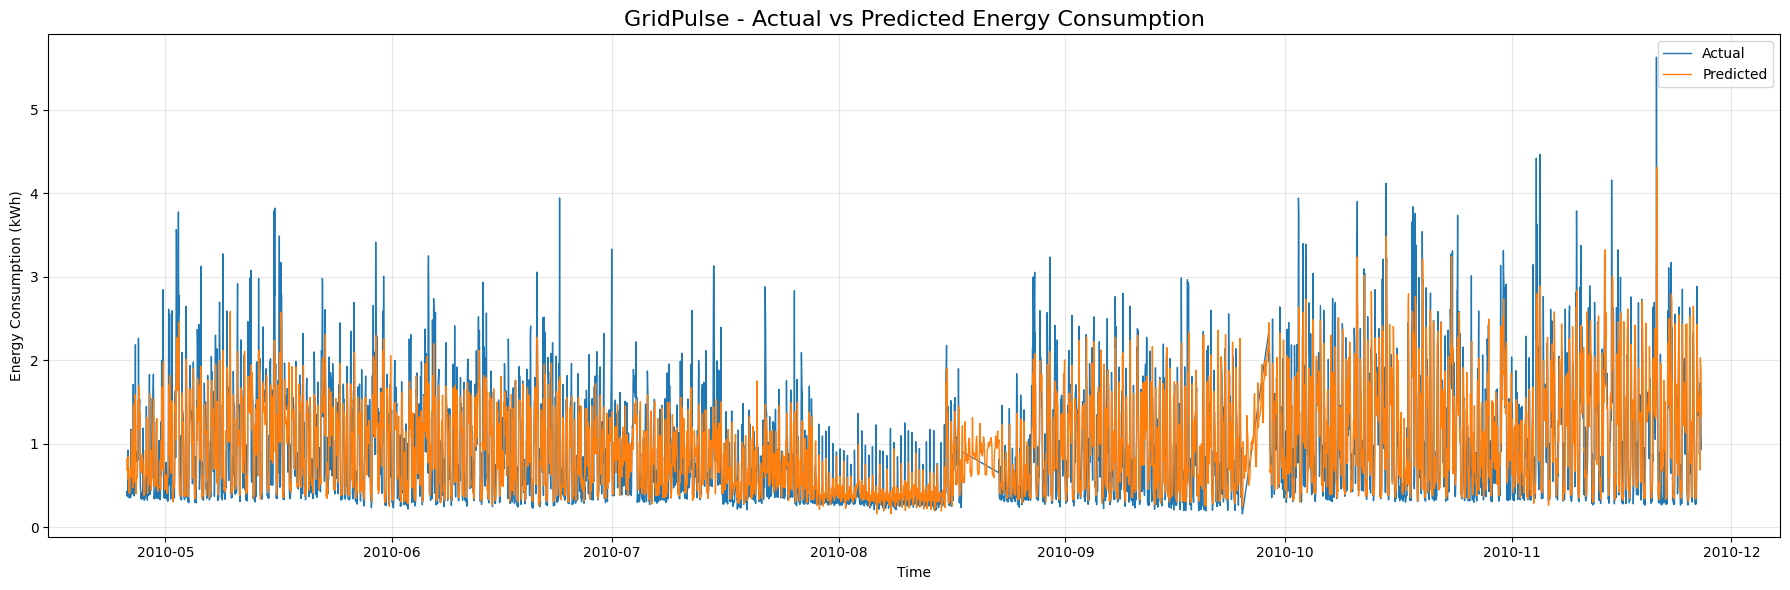

In [ ]:
# Actual vs predicted
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)

results_df = pd.DataFrame({
    "timestamp": test_df["timestamp"],
    "actual": y_test,
    "predicted": test_pred
})

plt.figure(figsize=(18,6))

plt.plot(
    results_df["timestamp"],
    results_df["actual"],
    label="Actual",
    linewidth=1
)

plt.plot(
    results_df["timestamp"],
    results_df["predicted"],
    label="Predicted",
    linewidth=1
)

plt.title(
    "GridPulse - Actual vs Predicted Energy Consumption",
    fontsize=16
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH /
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# forcast error

results_df["error"] = (
    results_df["actual"]
    -
    results_df["predicted"]
)

display(results_df.head())

print()

print("Mean Error:")
print(results_df["error"].mean())

print()

print("Error Std:")
print(results_df["error"].std())

,timestamp,actual,predicted,error
29425,2010-04-25 18:00:00,0.382767,0.685720,-0.302953
29426,2010-04-25 19:00:00,0.435367,0.824357,-0.388990
29427,2010-04-25 20:00:00,0.368333,0.800675,-0.432342
29428,2010-04-25 21:00:00,0.367833,0.644630,-0.276797
29429,2010-04-25 22:00:00,0.921433,0.579346,0.342087



Mean Error:
-0.005869261419249864

Error Std:
0.45393402052198895


In [ ]:
# Check columns

print(results_df.columns)

Index(['timestamp', 'actual', 'predicted'], dtype='object')


In [ ]:
# Create forecast error

results_df["error"] = (
    results_df["actual"]
    - results_df["predicted"]
)

results_df.head()

,timestamp,actual,predicted,error
29425,2010-04-25 18:00:00,0.382767,0.685720,-0.302953
29426,2010-04-25 19:00:00,0.435367,0.824357,-0.388990
29427,2010-04-25 20:00:00,0.368333,0.800675,-0.432342
29428,2010-04-25 21:00:00,0.367833,0.644630,-0.276797
29429,2010-04-25 22:00:00,0.921433,0.579346,0.342087


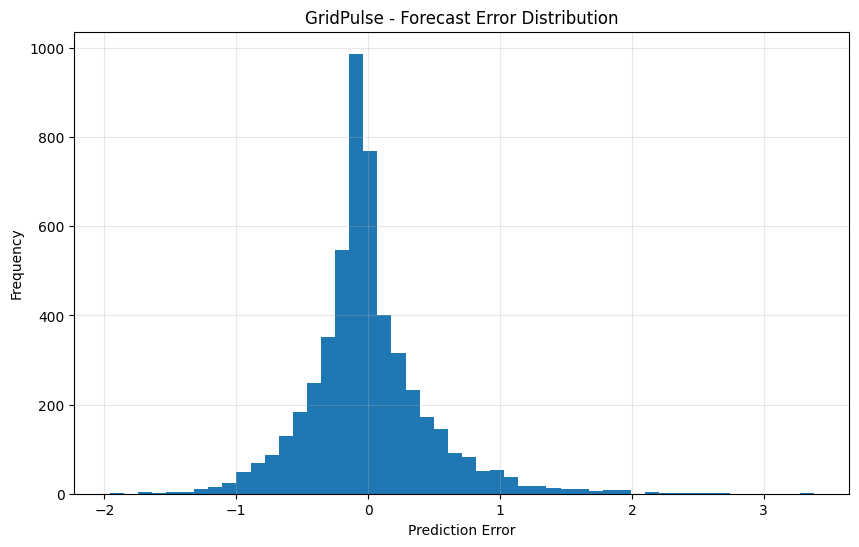

In [ ]:
# error distribution

FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
plt.figure(figsize=(10,6))

plt.hist(
    results_df["error"],
    bins=50
)

plt.title(
    "GridPulse - Forecast Error Distribution"
)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.savefig(
    FIGURES_PATH /
    "error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# feature importance

importance_df = pd.DataFrame({

    "feature": FEATURES,

    "importance":
    xgb_model.feature_importances_

})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

display(
    importance_df.head(15)
)

,feature,importance
12,lag_1,0.350003
18,rolling_mean_3,0.100961
9,hour_cos,0.070483
0,hour,0.045225
11,month_cos,0.042646
8,hour_sin,0.040596
15,lag_24,0.039482
17,lag_168,0.038096
7,is_weekend,0.031489
13,lag_2,0.021541


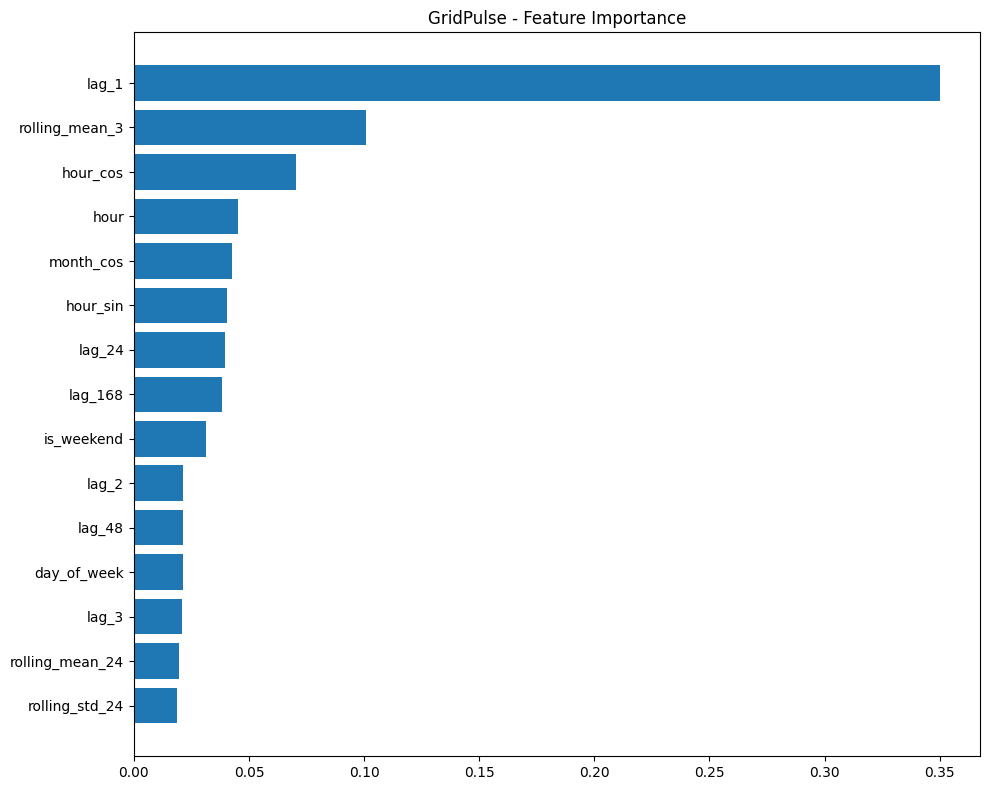

In [ ]:
# feature importance plot
FIGURES_PATH = Path(
    "/content/gridpulse/outputs/figures"
)
top_features = importance_df.head(15)

plt.figure(figsize=(10,8))

plt.barh(

    top_features["feature"],

    top_features["importance"]

)

plt.title(
    "GridPulse - Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(
    FIGURES_PATH /
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# save model

import joblib

MODEL_PATH = (
    "/content/gridpulse/models/"
    "gridpulse_xgboost.pkl"
)

joblib.dump(
    xgb_model,
    MODEL_PATH
)

print("Model saved:")
print(MODEL_PATH)

Model saved:
/content/gridpulse/models/gridpulse_xgboost.pkl


In [ ]:
# export prediction

results_df.to_csv(

    "/content/gridpulse/outputs/predictions/test_predictions.csv",

    index=False
)

print("Predictions exported.")

Predictions exported.


In [ ]:
import os

os.listdir("/content/gridpulse/outputs/figures")

['energy_by_quarter.png',
 'energy consumption over time.png',
 'short term vs long temr energy trend.png',
 'rolling_mean_analysis.png',
 'energy consumption density.png',
 'energy consumption boxplot.png',
 'average_energy_by_hour.png',
 '24 hour rolling standard deviation.png',
 'energy_by_month.png',
 'distribution of energy consumption.png',
 'energy_by_day_of_week.png',
 'potential demand peak.png',
 'autocorrelation_analysis.png']

In [ ]:
# model comparison chart

comparison_df = pd.DataFrame({

    "Model":[
        "XGBoost",
        "Last Value",
        "Seasonal Naive"
    ],

    "MAE":[
        0.313,
        0.372,
        0.503
    ],

    "RMSE":[
        0.454,
        0.575,
        0.749
    ]

})

comparison_df

,Model,MAE,RMSE
0,XGBoost,0.313,0.454
1,Last Value,0.372,0.575
2,Seasonal Naive,0.503,0.749


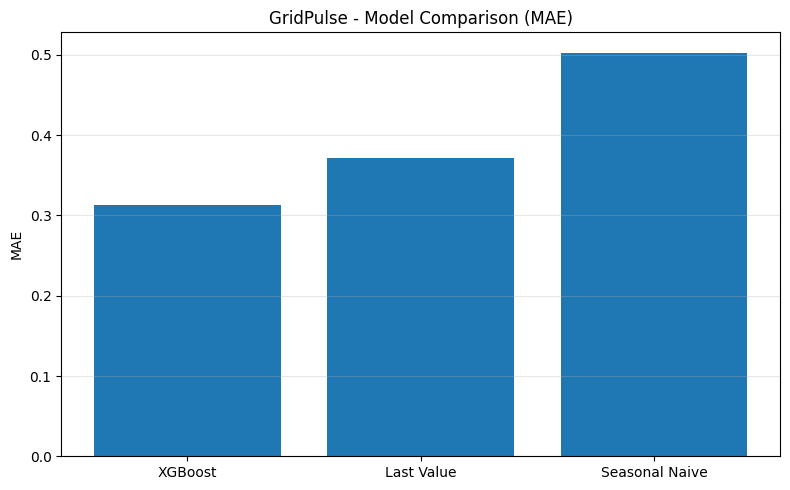

In [ ]:
# mae comparison

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.title(
    "GridPulse - Model Comparison (MAE)"
)

plt.ylabel("MAE")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

print(
    os.listdir(FIGURE_DIR)
)

['energy_by_quarter.png', 'error_distribution.png', 'feature_importance.png', 'model_comparison.png', 'energy consumption over time.png', 'short term vs long temr energy trend.png', 'rolling_mean_analysis.png', 'energy consumption density.png', 'energy consumption boxplot.png', 'actual_vs_predicted.png', 'average_energy_by_hour.png', '24 hour rolling standard deviation.png', 'energy_by_month.png', 'distribution of energy consumption.png', 'energy_by_day_of_week.png', 'potential demand peak.png', 'autocorrelation_analysis.png']


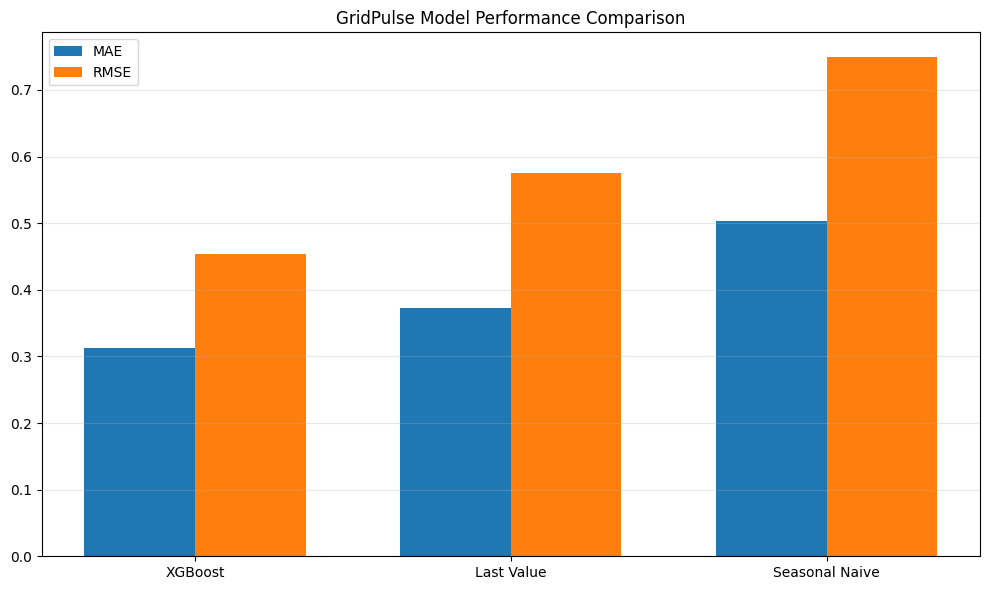

In [ ]:
# model comparison

comparison_df = pd.DataFrame({

    "Model":[
        "XGBoost",
        "Last Value",
        "Seasonal Naive"
    ],

    "MAE":[
        0.313,
        0.372,
        0.503
    ],

    "RMSE":[
        0.454,
        0.575,
        0.749
    ]

})

fig, ax = plt.subplots(
    figsize=(10,6)
)

x = np.arange(len(comparison_df))

width = 0.35

ax.bar(
    x - width/2,
    comparison_df["MAE"],
    width,
    label="MAE"
)

ax.bar(
    x + width/2,
    comparison_df["RMSE"],
    width,
    label="RMSE"
)

ax.set_xticks(x)

ax.set_xticklabels(
    comparison_df["Model"]
)

ax.set_title(
    "GridPulse Model Performance Comparison"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!zip -r figures.zip /content/gridpulse/outputs/figures

  adding: content/gridpulse/outputs/figures/ (stored 0%)
  adding: content/gridpulse/outputs/figures/energy_by_quarter.png (deflated 24%)
  adding: content/gridpulse/outputs/figures/error_distribution.png (deflated 34%)
  adding: content/gridpulse/outputs/figures/feature_importance.png (deflated 35%)
  adding: content/gridpulse/outputs/figures/model_comparison.png (deflated 35%)
  adding: content/gridpulse/outputs/figures/energy consumption over time.png (deflated 7%)
  adding: content/gridpulse/outputs/figures/short term vs long temr energy trend.png (deflated 4%)
  adding: content/gridpulse/outputs/figures/rolling_mean_analysis.png (deflated 6%)
  adding: content/gridpulse/outputs/figures/energy consumption density.png (deflated 20%)
  adding: content/gridpulse/outputs/figures/energy consumption boxplot.png (deflated 33%)
  adding: content/gridpulse/outputs/figures/actual_vs_predicted.png (deflated 3%)
  adding: content/gridpulse/outputs/figures/average_energy_by_hour.png (deflated 1

In [ ]:
from google.colab import files

files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r GridPulse-Energy-Forecasting.zip /content/gridpulse

  adding: content/gridpulse/ (stored 0%)
  adding: content/gridpulse/models/ (stored 0%)
  adding: content/gridpulse/models/gridpulse_xgboost.pkl (deflated 70%)
  adding: content/gridpulse/outputs/ (stored 0%)
  adding: content/gridpulse/outputs/metrics/ (stored 0%)
  adding: content/gridpulse/outputs/metrics/baseline_results.csv (deflated 27%)
  adding: content/gridpulse/outputs/figures/ (stored 0%)
  adding: content/gridpulse/outputs/figures/energy_by_quarter.png (deflated 24%)
  adding: content/gridpulse/outputs/figures/error_distribution.png (deflated 34%)
  adding: content/gridpulse/outputs/figures/feature_importance.png (deflated 35%)
  adding: content/gridpulse/outputs/figures/model_comparison.png (deflated 35%)
  adding: content/gridpulse/outputs/figures/energy consumption over time.png (deflated 7%)
  adding: content/gridpulse/outputs/figures/short term vs long temr energy trend.png (deflated 4%)
  adding: content/gridpulse/outputs/figures/rolling_mean_analysis.png (deflated 6

In [ ]:
from google.colab import files

files.download(
    "GridPulse-Energy-Forecasting.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

for root, dirs, files in os.walk("/content/gridpulse"):
    for file in files:
        print(os.path.join(root, file))

/content/gridpulse/models/gridpulse_xgboost.pkl
/content/gridpulse/outputs/metrics/baseline_results.csv
/content/gridpulse/outputs/figures/energy_by_quarter.png
/content/gridpulse/outputs/figures/error_distribution.png
/content/gridpulse/outputs/figures/feature_importance.png
/content/gridpulse/outputs/figures/model_comparison.png
/content/gridpulse/outputs/figures/energy consumption over time.png
/content/gridpulse/outputs/figures/short term vs long temr energy trend.png
/content/gridpulse/outputs/figures/rolling_mean_analysis.png
/content/gridpulse/outputs/figures/energy consumption density.png
/content/gridpulse/outputs/figures/energy consumption boxplot.png
/content/gridpulse/outputs/figures/actual_vs_predicted.png
/content/gridpulse/outputs/figures/average_energy_by_hour.png
/content/gridpulse/outputs/figures/24 hour rolling standard deviation.png
/content/gridpulse/outputs/figures/energy_by_month.png
/content/gridpulse/outputs/figures/distribution of energy consumption.png
/conte

In [ ]:
baseline_results.to_csv(
    "/content/gridpulse/outputs/metrics/baseline_results.csv",
    index=False
)

In [ ]:
all_results.to_csv(
    "/content/gridpulse/outputs/metrics/model_results.csv",
    index=False
)
